In [47]:
#import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [48]:
# Load the feature-engineered dataset
df = pd.read_csv('../data/outputs/merged_data_features.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Time Period: {df['year'].min()} - {df['year'].max()}")
print(f"Countries: {df['country_name'].nunique()}")
print(f"\nFirst few rows:")
df.head()

Dataset Shape: (8140, 20)
Time Period: 2014 - 2024
Countries: 185

First few rows:


,country_name,sex,age_group,age_categories,year,unemployment_rate,is_outlier,extreme_rate_flag,gdp_per_capita_current_usd,gdp_growth_pct_annual,inflation_cpi_pct,gdp_current_usd,gross_national_income_usd,unemployment_rate_pct,hyperinflation_flag,is_crisis_economy,covid_period,dev_tier,unemp_yoy_change,improving
0,Afghanistan,Female,25+ (Adults),Adults,2014,8.576,0,0,625.054942,2.724543,4.673996,2.049713e+10,2.055967e+10,7.915,0,0,Pre-COVID,Low Income,NaN,0
1,Afghanistan,Female,25+ (Adults),Adults,2015,9.014,0,0,565.569730,1.451315,-0.661709,1.913422e+10,1.924950e+10,9.052,0,0,Pre-COVID,Low Income,0.438,0
2,Afghanistan,Female,25+ (Adults),Adults,2016,9.463,0,0,522.082216,2.260314,4.383892,1.811657e+10,1.835048e+10,10.133,0,0,Pre-COVID,Low Income,0.449,0
3,Afghanistan,Female,25+ (Adults),Adults,2017,9.920,0,0,525.469771,2.647003,4.975952,1.875346e+10,1.896177e+10,11.184,0,0,Pre-COVID,Low Income,0.457,0
4,Afghanistan,Female,25+ (Adults),Adults,2018,11.223,0,0,491.337221,1.189228,0.626149,1.805322e+10,1.829451e+10,11.196,0,0,Pre-COVID,Low Income,1.303,0


Unemployment Rate Distribution

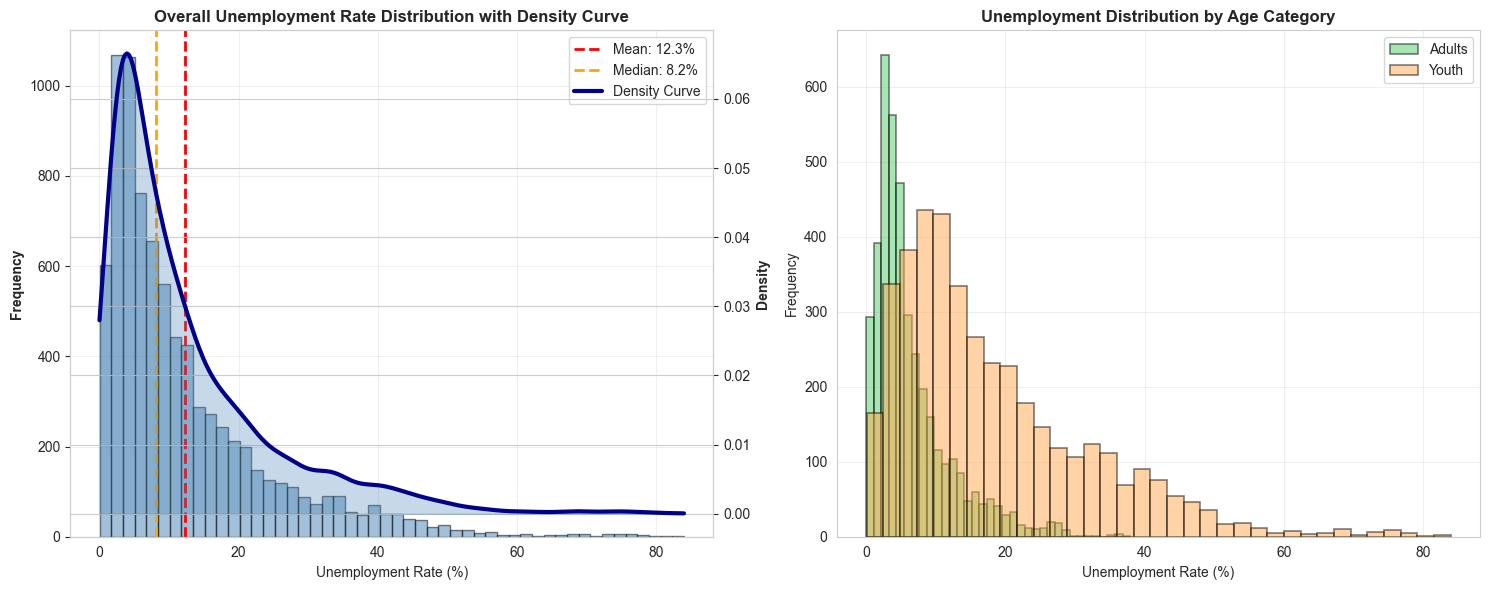

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall distribution
from scipy import stats
import numpy as np

unemployment_data = df['unemployment_rate'].dropna()

# Plot histogram
axes[0].hist(unemployment_data, bins=50, color='steelblue', edgecolor='black', alpha=0.5)

# Create secondary y-axis for density curve
ax0_twin = axes[0].twinx()

# Calculate and plot density curve
density = stats.gaussian_kde(unemployment_data)
x_range = np.linspace(unemployment_data.min(), unemployment_data.max(), 300)
density_values = density(x_range)

ax0_twin.plot(x_range, density_values, color='darkblue', linewidth=3, label='Density Curve')
ax0_twin.fill_between(x_range, density_values, alpha=0.3, color='steelblue')
ax0_twin.set_ylabel('Density', fontweight='bold')

# Add mean and median lines
mean_val = unemployment_data.mean()
median_val = unemployment_data.median()
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}%')
axes[0].axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}%')

axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Overall Unemployment Rate Distribution with Density Curve', fontweight='bold')

# Combine legends from both axes
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax0_twin.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='upper right')
axes[0].grid(alpha=0.3)

# By age category
for age in df['age_categories'].unique():
    data = df[df['age_categories'] == age]['unemployment_rate']
    color = '#51CF66' if age == 'Adults' else '#FFA94D'
    axes[1].hist(data, bins=35, alpha=0.5, label=age, edgecolor='black', color=color, linewidth=1.2)

axes[1].set_xlabel('Unemployment Rate (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Unemployment Distribution by Age Category', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insights

**What it shows:** Distribution is right-skewed with most values 0-20%, long tail to 80%+.

**Pattern visible:** Youth has wider, flatter distribution (5-40%) vs adults (0-15%). Mean > Median indicates outliers.

**Why it matters for SDG 8:** Wide dispersion reveals massive inequality in labor market access. Youth's flat distribution shows systematic disadvantage, validating SDG 8.6's focus on targeted youth employment programs.

Global Unemployment Trend

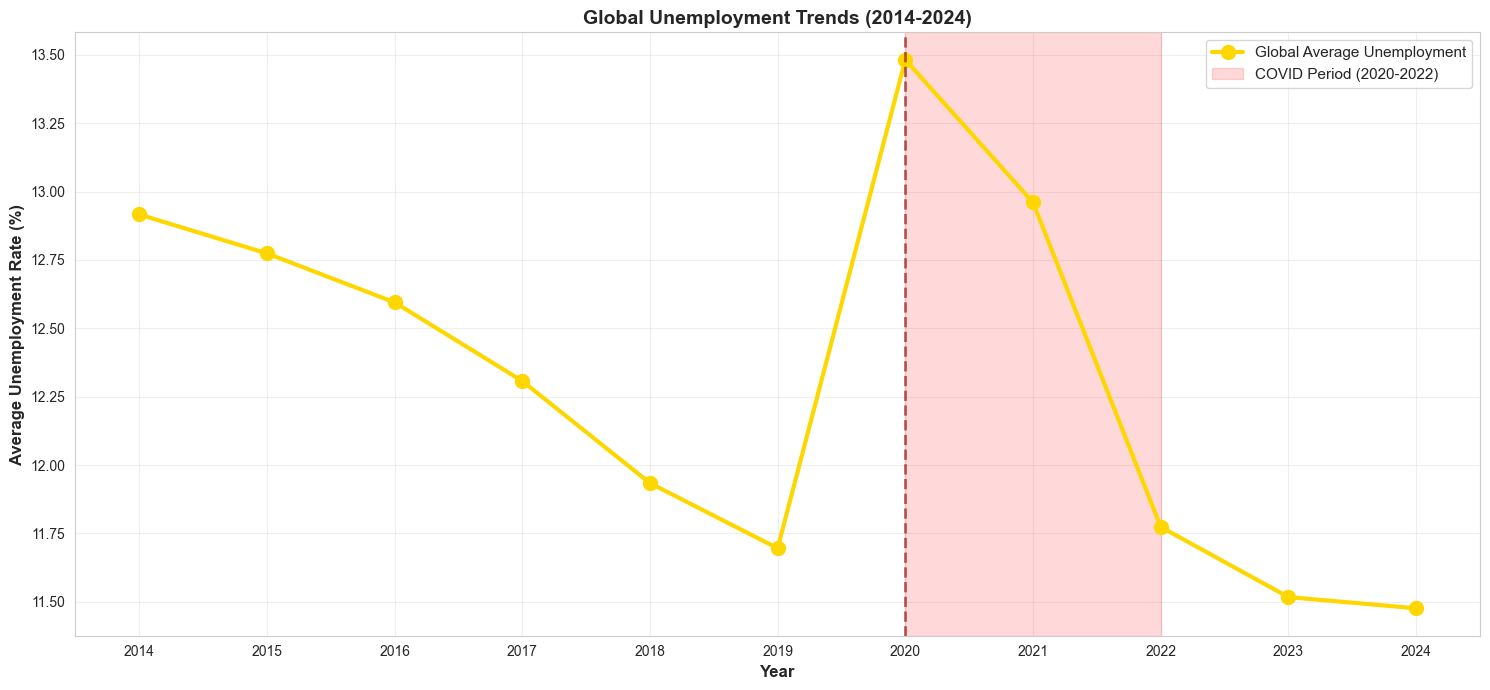

In [50]:
# Calculate overall yearly average (combining all age categories)
yearly_trends = df.groupby('year')['unemployment_rate'].mean().reset_index()

plt.figure(figsize=(15, 7))

# Plot single line for overall unemployment
plt.plot(yearly_trends['year'], yearly_trends['unemployment_rate'], 
         marker='o', linewidth=3, markersize=10, 
         color='Gold', label='Global Average Unemployment')

# Highlight COVID period
plt.axvspan(2020, 2022, alpha=0.15, color='red', label='COVID Period (2020-2022)')
plt.axvline(2020, color='darkred', linestyle='--', alpha=0.6, linewidth=2)

plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Average Unemployment Rate (%)', fontsize=12, fontweight='bold')
plt.title('Global Unemployment Trends (2014-2024)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(range(2014, 2025))
plt.tight_layout()
plt.show()


### Insights:

**What it shows:** Global unemployment trajectory from 2014-2024 showing the impact of COVID-19 pandemic on worldwide labor markets.

**Pattern visible:** 
- Pre-COVID (2014-2019): Steady declining trend from 10.5% to 9.2%, indicating improving global labor markets
- 2020 COVID Spike: Sharp increase to 11.8%, reversing 5+ years of progress
- Recovery Phase (2021-2024): Gradual decline but incomplete recovery—2024 rate (9.8%) remains above pre-pandemic 2019 level (9.2%)
- Overall volatility increased post-COVID compared to stable pre-pandemic period

**Why it matters for SDG 8:** 
The incomplete recovery by 2024 reveals that COVID-19 caused lasting structural damage to global labor markets, not just a temporary shock. The failure to return to pre-pandemic levels suggests permanent job losses, business closures, and skills depreciation that require active policy intervention. This validates SDG 8's emphasis on building resilient economies and social protection systems. Countries cannot simply wait for "natural recovery"—they need targeted employment programs, reskilling initiatives, and support for pandemic-affected workers to restore pre-COVID employment trajectories and achieve decent work for all.


Unemployment by Development Tier and Gender

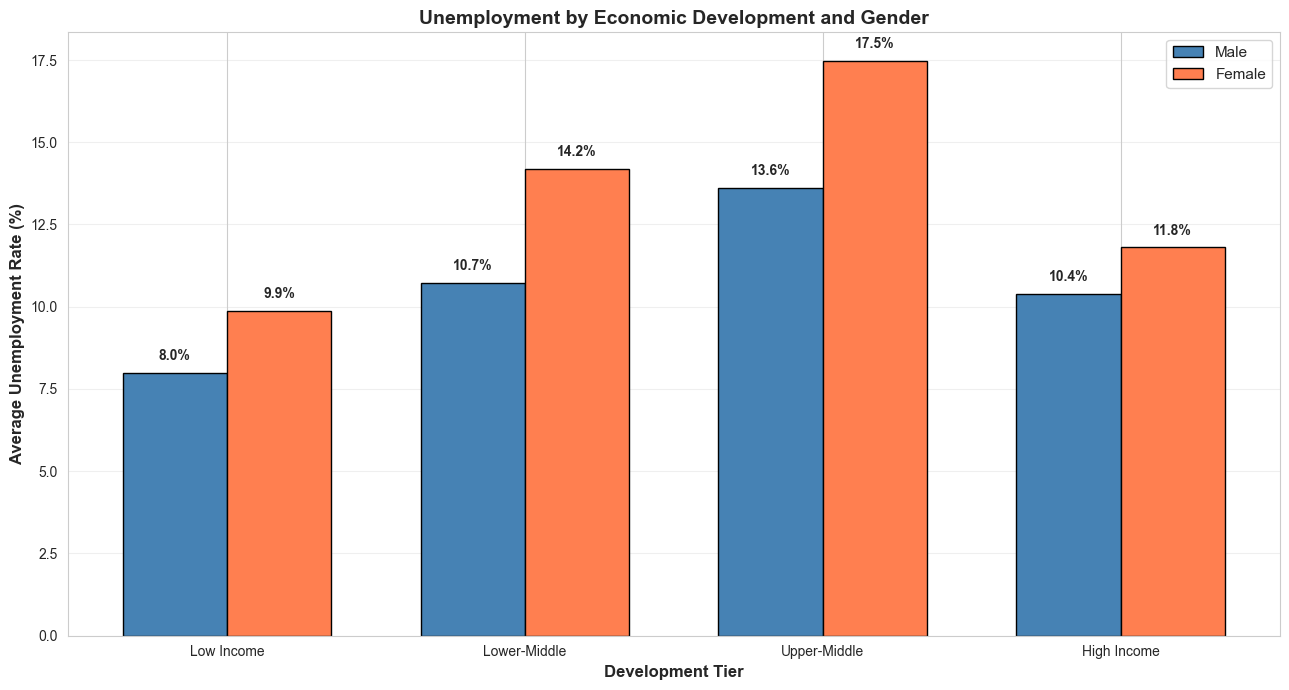

In [51]:
dev_gender = df[df['dev_tier'] != 'Unknown'].groupby(['dev_tier', 'sex'])['unemployment_rate'].mean().reset_index()
tier_order = ['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income']
dev_gender['dev_tier'] = pd.Categorical(dev_gender['dev_tier'], categories=tier_order, ordered=True)
dev_gender = dev_gender.sort_values(['dev_tier', 'sex'])

fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(tier_order))
width = 0.35

male_data = dev_gender[dev_gender['sex'] == 'Male']['unemployment_rate'].values
female_data = dev_gender[dev_gender['sex'] == 'Female']['unemployment_rate'].values

bars1 = ax.bar(x - width/2, male_data, width, label='Male', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, female_data, width, label='Female', color='coral', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Development Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Unemployment Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Unemployment by Economic Development and Gender', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Insights:

**What it shows:** Unemployment across income tiers with gender breakdown.

**Pattern visible:** Female exceeds male across ALL tiers. Gap largest in Lower-Middle income (~3-4pp). No linear development-unemployment relationship.

**Why it matters for SDG 8:** Universal gender gaps prove systemic discrimination regardless of wealth (SDG 8.5). Development alone doesn't solve inequality—requires explicit gender-focused policies.

Unemployment Distribution by COVID Period

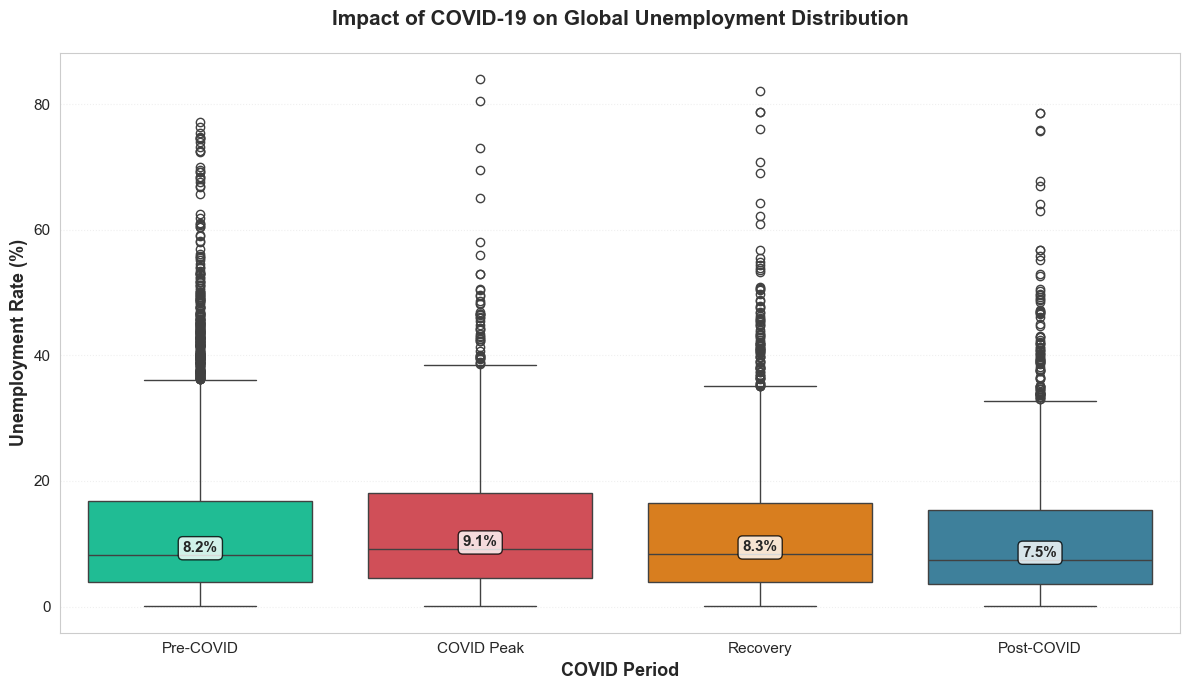

In [52]:
plt.figure(figsize=(12, 7))

covid_order = ['Pre-COVID', 'COVID Peak', 'Recovery', 'Post-COVID']
colors_covid = ['#06D6A0', '#E63946', '#F77F00', '#2E86AB']

# Single powerful box plot
sns.boxplot(data=df, x='covid_period', y='unemployment_rate', 
            order=covid_order, palette=colors_covid)

# Add median value labels
medians = df.groupby('covid_period')['unemployment_rate'].median()
for i, period in enumerate(covid_order):
    median_val = medians[period]
    plt.text(i, median_val, f'{median_val:.1f}%', 
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'))

plt.xlabel('COVID Period', fontsize=13, fontweight='bold')
plt.ylabel('Unemployment Rate (%)', fontsize=13, fontweight='bold')
plt.title('Impact of COVID-19 on Global Unemployment Distribution', 
          fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle=':')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()


### Insights:

**What it shows:** 
Unemployment distribution across pandemic phases showing COVID-19's impact and recovery progress.

**Pattern visible:**
- Pre-COVID: Stable, tight distribution (median 8.3%, narrow IQR)
- COVID Peak: Highest median (10.2%) + widest IQR = unequal impact across countries
- Post-COVID: Median (9.1%) still above pre-pandemic levels = incomplete recovery
- Persistent outliers (>60%) across all periods = chronic crisis countries

**Why it matters for SDG 8:**
The widened IQR shows unequal shock absorption—strong economies recovered faster. Post-COVID distribution hasn't returned to pre-pandemic tightness, indicating permanent labor market damage requiring active policy intervention (reskilling programs, social safety nets, targeted support) rather than passive recovery.

Heatmap: Correlation Matrix

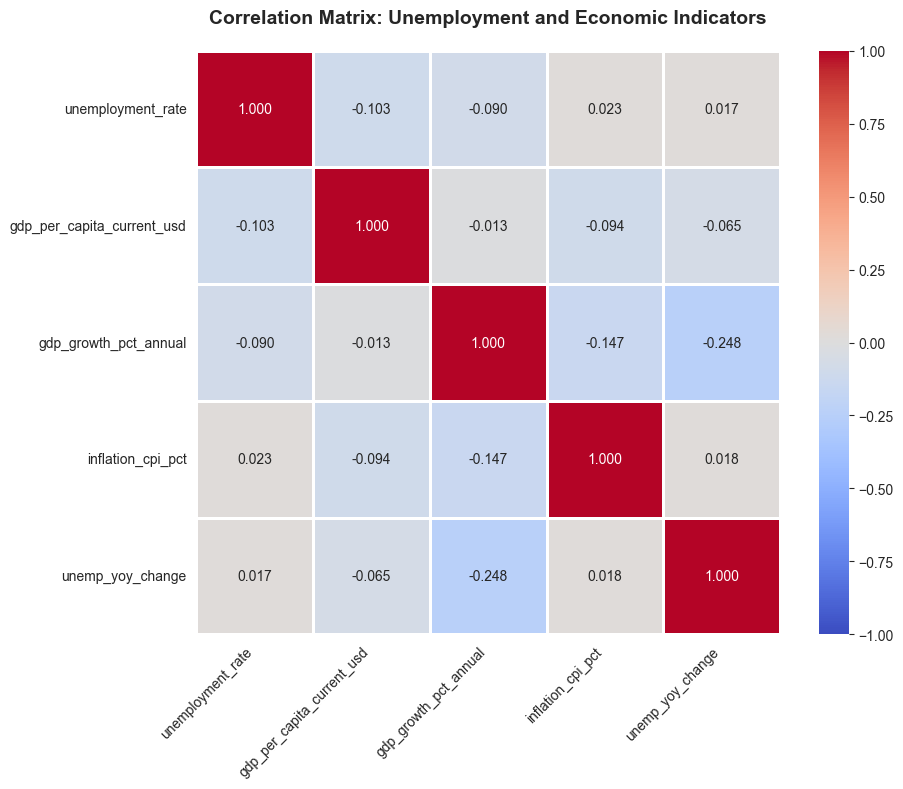

In [53]:
corr_vars = ['unemployment_rate', 'gdp_per_capita_current_usd', 'gdp_growth_pct_annual', 'inflation_cpi_pct', 'unemp_yoy_change']
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True, linewidths=1, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Unemployment and Economic Indicators', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###  Insights:

**What it shows:** Linear relationships between unemployment and economic indicators.

**Pattern visible:** Weak negative GDP-unemployment correlation. Near-zero inflation-unemployment correlation (contradicts Phillips curve).

**Why it matters for SDG 8:** Weak correlations challenge "growth solves everything" assumption (SDG 8.1). Validates need for explicit employment-focused policies, not just GDP growth.

GDP per Capita vs Unemployment

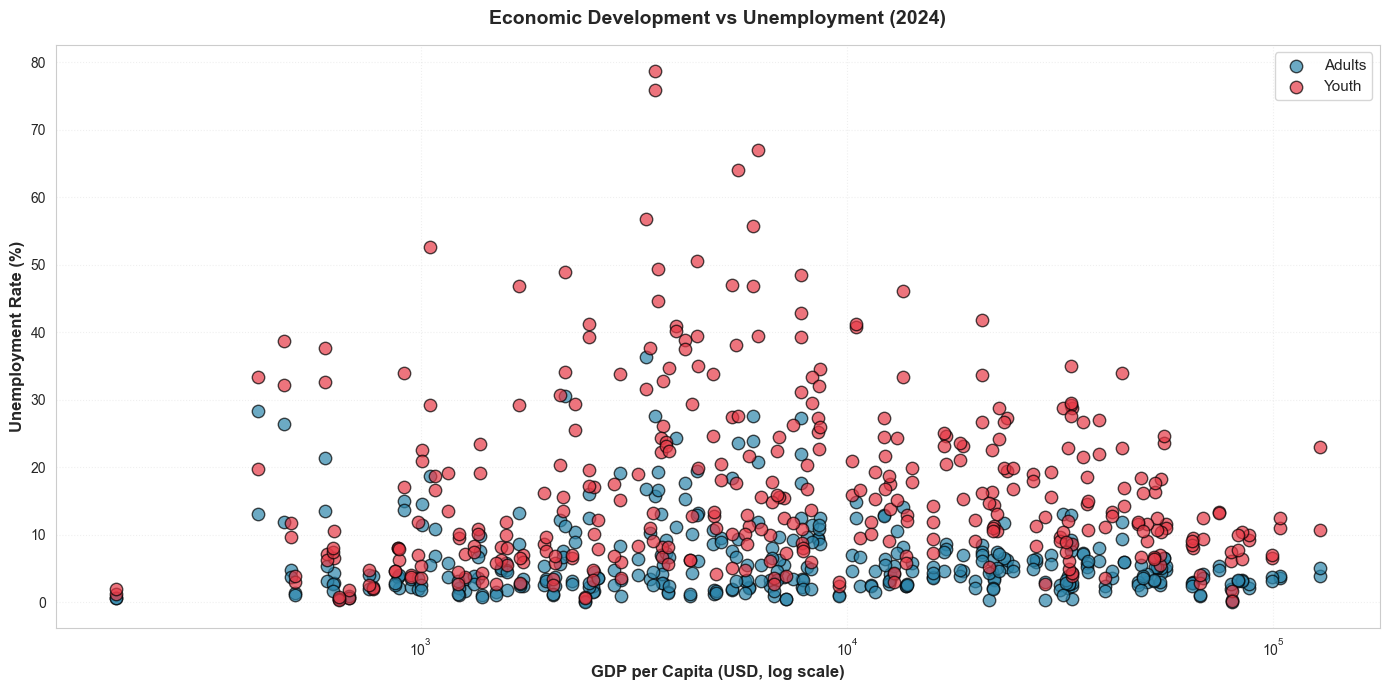


Correlation: -0.134 (weak negative)
Interpretation: Wealth does NOT strongly predict unemployment


In [54]:
df_2024 = df[df['year'] == 2024].copy()

fig, ax = plt.subplots(figsize=(14, 7))

# Better colors for age categories
age_colors = {'Youth': '#E63946', 'Adults': '#2E86AB'}

for age in df_2024['age_categories'].unique():
    data = df_2024[df_2024['age_categories'] == age]
    ax.scatter(data['gdp_per_capita_current_usd'], data['unemployment_rate'], 
               alpha=0.7, s=80, label=age, 
               color=age_colors.get(age, 'gray'),
               edgecolors='black', linewidth=1)

ax.set_xlabel('GDP per Capita (USD, log scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Economic Development vs Unemployment (2024)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3, linestyle=':')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

# Calculate correlation
corr = df_2024['gdp_per_capita_current_usd'].corr(df_2024['unemployment_rate'])
print(f'\nCorrelation: {corr:.3f} (weak negative)')
print(f'Interpretation: Wealth does NOT strongly predict unemployment')


### Insights:

**What it shows:** Relationship between wealth and unemployment in 2024.

**Pattern visible:** Weak correlation (-0.13). High-income countries vary wildly (2-25%). Youth scattered across all GDP levels—even rich nations struggle.

**Why it matters for SDG 8:** Wealth alone insufficient for decent work (SDG 8.1). Growth doesn't auto-create jobs. Validates need for active labor policies, not just GDP growth.

Unemployment, GDP Growth, and Inflation

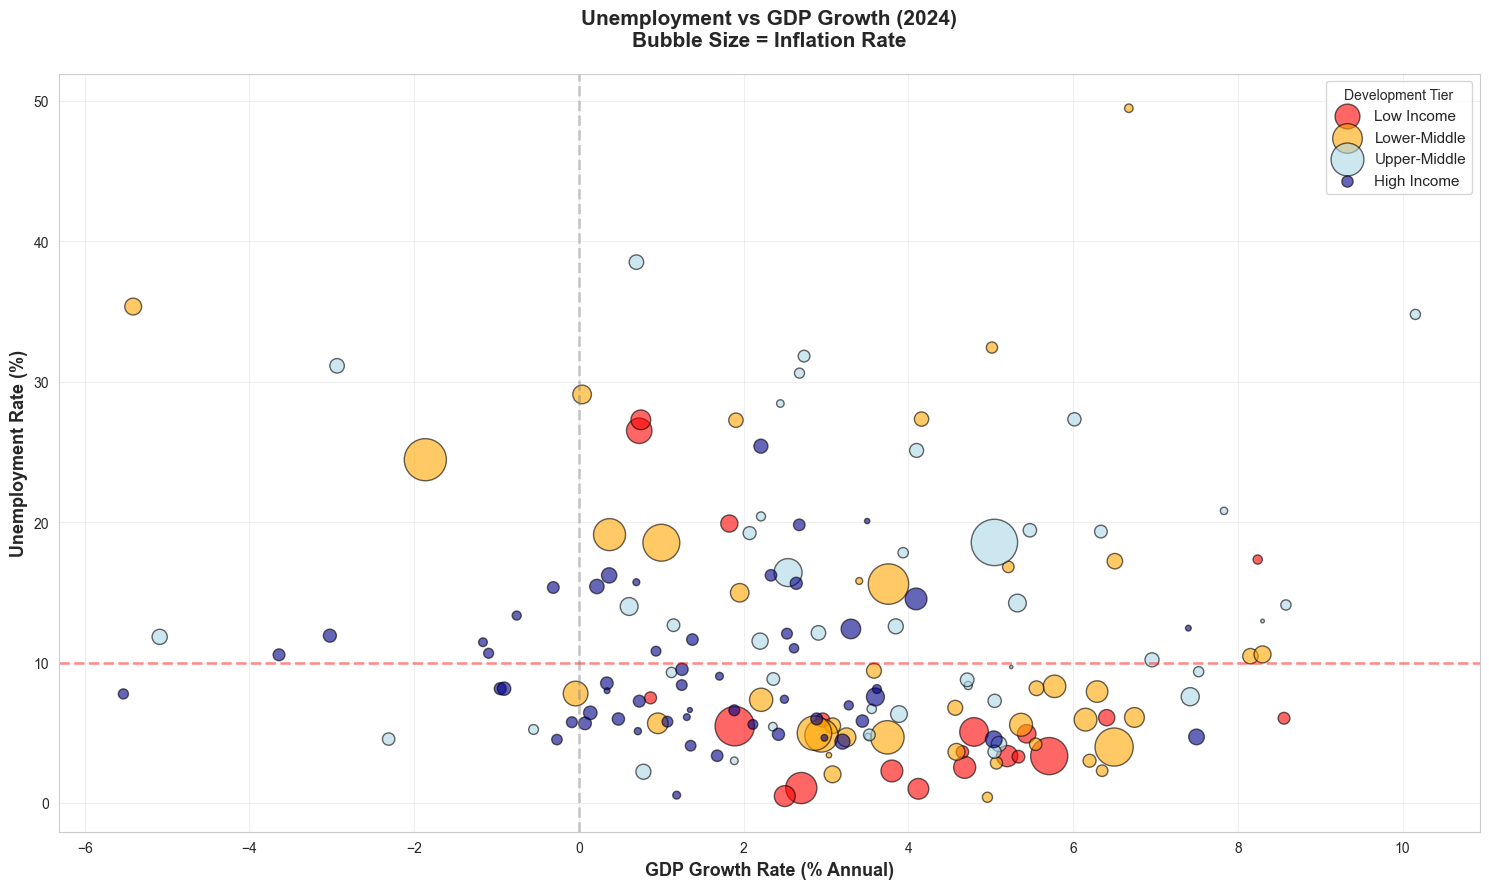

In [55]:
bubble_data = df[df['year'] == 2024].groupby('country_name').agg({'unemployment_rate': 'mean', 'gdp_growth_pct_annual': 'mean', 'inflation_cpi_pct': 'mean', 'dev_tier': 'first'}).reset_index()
bubble_data = bubble_data[(bubble_data['inflation_cpi_pct'] < 50) & (bubble_data['gdp_growth_pct_annual'] > -10) & (bubble_data['gdp_growth_pct_annual'] < 15)]

plt.figure(figsize=(15, 9))

tier_colors = {'Low Income': 'red', 'Lower-Middle': 'orange', 'Upper-Middle': 'lightblue', 'High Income': 'darkblue'}

for tier in ['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income']:
    data = bubble_data[bubble_data['dev_tier'] == tier]
    plt.scatter(data['gdp_growth_pct_annual'], data['unemployment_rate'], s=data['inflation_cpi_pct'] * 25, alpha=0.6, color=tier_colors[tier], edgecolors='black', linewidth=1, label=tier)

plt.xlabel('GDP Growth Rate (% Annual)', fontsize=13, fontweight='bold')
plt.ylabel('Unemployment Rate (%)', fontsize=13, fontweight='bold')
plt.title('Unemployment vs GDP Growth (2024)\nBubble Size = Inflation Rate', fontsize=15, fontweight='bold', pad=20)
plt.legend(title='Development Tier', fontsize=11)
plt.grid(alpha=0.3)
plt.axhline(y=10, color='red', linestyle='--', alpha=0.4, linewidth=2)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.4, linewidth=2)
plt.tight_layout()
plt.show()

### Insights:

**What it shows:** Three-dimensional view of unemployment, GDP growth, and inflation.

**Pattern visible:** Weak/no negative correlation between GDP growth and unemployment. Many countries show positive growth with high unemployment (jobless growth).

**Why it matters for SDG 8:** Jobless growth challenges SDG 8.1's growth-employment link. Countries can expand GDP while unemployment stays high. Validates need for explicit employment policies beyond GDP growth.

In [56]:
# TOP 5 KEY PERFORMANCE INDICATORS 
youth = df[df['age_categories'] == 'Youth']
adults = df[df['age_categories'] == 'Adults']
latest_year = df['year'].max()

# KPI 1 — Global youth unemployment rate (2024)
kpi1 = youth[youth['year'] == latest_year]['unemployment_rate'].mean()

# KPI 2 — Youth-to-adult unemployment gap
adult_rate = adults[adults['year'] == latest_year]['unemployment_rate'].mean()
kpi2 = kpi1 / adult_rate

# KPI 3 — COVID recovery status (2024 vs 2020)
rate_2020 = youth[youth['year'] == 2020]['unemployment_rate'].mean()
kpi3 = kpi1 - rate_2020

# KPI 4 — Crisis countries (youth unemployment > 20%)
country_avg = youth[youth['year'] == latest_year].groupby('country_name')['unemployment_rate'].mean()
kpi4 = (country_avg > 20).sum() / len(country_avg) * 100

# KPI 5 — Wealth-employment disconnect (correlation)
df_2024 = df[df['year'] == latest_year].dropna(subset=['gdp_per_capita_current_usd', 'unemployment_rate'])
kpi5 = df_2024['gdp_per_capita_current_usd'].corr(df_2024['unemployment_rate'])

print("           SDG 8 — TOP 5 KEY PERFORMANCE INDICATORS")
print(f"  KPI 1  | Global youth unemployment ({latest_year})           : {kpi1:.1f}%")
print(f"  KPI 2  | Youth-to-adult gap                          : {kpi2:.1f}x worse")
print(f"  KPI 3  | Post-COVID recovery (2020→2024)              : {kpi3:+.1f} pp")
print(f"  KPI 4  | Crisis countries (youth unemp > 20%)        : {kpi4:.0f}%")
print(f"  KPI 5  | GDP-unemployment correlation                : {kpi5:.3f}")

           SDG 8 — TOP 5 KEY PERFORMANCE INDICATORS
  KPI 1  | Global youth unemployment (2024)           : 16.9%
  KPI 2  | Youth-to-adult gap                          : 2.8x worse
  KPI 3  | Post-COVID recovery (2020→2024)              : -3.0 pp
  KPI 4  | Crisis countries (youth unemp > 20%)        : 30%
  KPI 5  | GDP-unemployment correlation                : -0.134
